# Data extraction from ChEMBL

## Aim
Download all molecules that have been tested against the **epidermal growth factor receptor (EGFR) kinase**.
- Find ligands which were tested on a certain target
- Filter by available bioactivity data
- Calculate pIC50 values
- Merge dataframes
- Draw and display molecules

## For more details
https://github.com/volkamerlab/teachopencadd/blob/master/teachopencadd/talktorials/T001_query_chembl/talktorial.ipynb

## Instructions
Replace XXX with the appropriate code

## Configuration

In [64]:
# Magic commands
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
# Imports
# 1. Standard library imports
import math
from pathlib import Path
import sys
sys.path.append('../my_modules') # to tell where to find local modules

# 2. Third-party library imports
from chembl_webresource_client.new_client import new_client
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import (
    Draw,
    PandasTools
)
PandasTools.RenderImagesInAllDataFrames(images=True) # to molecules as images in DataFrames
from rdkit.Chem.Draw import IPythonConsole # needed to show molecules
# from rdkit.Chem.Draw.MolDrawing import MolDrawing, DrawingOptions # only needed if modifying defaults

# 3. Local application imports
import kernel_infos

In [66]:
# Information about the kernel
kernel_infos.show_kernel_info()

=== Kernel Information ===
Python version: 3.14.0 (main, Oct  7 2025, 09:34:52) [Clang 17.0.0 (clang-1700.0.13.3)]
Executable: /Users/bourg/Enseignement/GSON/gson_sbc/.venv/bin/python3
Platform: macOS-15.7.2-arm64-arm-64bit-Mach-O
IPython version: 9.7.0


In [67]:
# Global variables
HERE = Path().resolve()
print(f'{HERE}')
ROOT = HERE.parent
print(f'{ROOT}')
DATA = ROOT / 'data'
print(f'{DATA}')

/Users/bourg/Enseignement/GSON/gson_sbc/notebooks
/Users/bourg/Enseignement/GSON/gson_sbc
/Users/bourg/Enseignement/GSON/gson_sbc/data


## Create resource objects for API access.

In [68]:
targets_api = new_client.target
compounds_api = new_client.molecule
bioactivities_api = new_client.activity

## Target data
* Get uniprot-id (http://www.uniprot.org/uniprot/P00533) of the target of interest (EGFR kinase) from UniProt website (https://www.uniprot.org/)
* Use uniprot-id to get target information

In [69]:
# Target
uniprot_id = 'P00533'

In [70]:
# Get target information from ChEMBL but restricted to specified values only
targets_P00533 = targets_api.get(target_components__accession=uniprot_id) \
                       .only('target_chembl_id', 'organism', 'pref_name', 'target_type')

In [71]:
# The resulting object
print(type(targets_P00533))

<class 'chembl_webresource_client.query_set.QuerySet'>


In [72]:
# Get information about the resulting object
targets_P00533?

Type:        QuerySet
String form: [{'organism': 'Homo sapiens', 'pref_name': 'Epidermal growth factor receptor', 'target_chembl_id' <...> id': 'CHEMBL3137284', 'target_type': 'CHIMERIC PROTEIN'}, '...(remaining elements truncated)...']
Length:      11
File:        ~/Enseignement/GSON/gson_sbc/.venv/lib/python3.14/site-packages/chembl_webresource_client/query_set.py
Docstring:   <no docstring>

What does a chembl_webresource_client.query_set.QuerySet consist of ?  
A list of dictionnaries

In [73]:
# How many elements in the resulting object?
print(f'{len(targets_P00533)} target(s) found.')

11 target(s) found.


In [74]:
# Download target data from ChEMBL in a dataframe
targets_P00533_df = pd.DataFrame.from_records(targets_P00533)

In [75]:
# Display the dataframe
targets_P00533_df

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Epidermal growth factor receptor,CHEMBL203,SINGLE PROTEIN
1,Homo sapiens,Epidermal growth factor receptor,CHEMBL203,SINGLE PROTEIN
2,Homo sapiens,Epidermal growth factor receptor and ErbB2 (HE...,CHEMBL2111431,PROTEIN FAMILY
3,Homo sapiens,Epidermal growth factor receptor,CHEMBL2363049,PROTEIN FAMILY
4,Homo sapiens,MER intracellular domain/EGFR extracellular do...,CHEMBL3137284,CHIMERIC PROTEIN
5,Homo sapiens,Protein cereblon/Epidermal growth factor receptor,CHEMBL4523680,PROTEIN-PROTEIN INTERACTION
6,Homo sapiens,EGFR/PPP1CA,CHEMBL4523747,PROTEIN-PROTEIN INTERACTION
7,Homo sapiens,von Hippel-Lindau disease tumor suppressor/EGFR,CHEMBL4523998,PROTEIN-PROTEIN INTERACTION
8,Homo sapiens,Baculoviral IAP repeat-containing protein 2/Ep...,CHEMBL4802031,PROTEIN-PROTEIN INTERACTION
9,Homo sapiens,CCN2-EGFR,CHEMBL5465557,PROTEIN-PROTEIN INTERACTION


## Select target : target_chembl_id


**CHEMBL203**: a single protein, represents the human Epidermal growth factor receptor (EGFR, also named erbB1)

In [76]:
# Select the first target and display it
target = targets_P00533_df.iloc[0]
target

organism                                Homo sapiens
pref_name           Epidermal growth factor receptor
target_chembl_id                           CHEMBL203
target_type                           SINGLE PROTEIN
Name: 0, dtype: object

In [77]:
# Save the selected CHEMBL ID in chembl_id variable and print it
chembl_id = target['target_chembl_id']
print(f"The target ChEMBL ID is {chembl_id}")

The target ChEMBL ID is CHEMBL203


## Get bioactivity data

### Fetch filtered bioactivity data for the target from ChEMBL

- human proteins,
- bioactivity type IC50,
- exact measurements (relation '='), and
- binding data (assay type 'B').

In [78]:
bioactivities_qs = bioactivities_api.filter(target_chembl_id=chembl_id) \
                      .filter(type='IC50') \
                      .filter(relation='=') \
                      .filter(assay_type='B') \
                      .only('activity_id', 
                      'assay_chembl_id', 
                      'assay_description', 
                      'assay_type',
                      'molecule_chembl_id', 
                      'type', 
                      'units', 
                      'relation', 
                      'value',
                      'target_chembl_id', 
                      'target_organism')

In [79]:
print(f"type(bioactivities_qs) = {type(bioactivities_qs)}")
print(f"Number of bioactivites = {len(bioactivities_qs)}")
print(f"type(bioactivities_qs[0]) = {type(bioactivities_qs[0])}")
print(f"Number of bioactivites in bioactivities_qs[0] = {len(bioactivities_qs[0])}")

type(bioactivities_qs) = <class 'chembl_webresource_client.query_set.QuerySet'>
Number of bioactivites = 17107
type(bioactivities_qs[0]) = <class 'dict'>
Number of bioactivites in bioactivities_qs[0] = 11


In [80]:
## Download bioactivity data in a dataframe (could take a long time so you can use pre-downloaded data below)
# bioactivities_df = pd.DataFrame.from_dict(bioactivities_qs)

In [81]:
## Save data to CSV file, zip it and delete CSV file
# import zipfile
# import os
# bioactivities_ChEMBL36_csv_file_path = DATA / "EGFR_bioactivities_CHEMBL36.csv"
# bioactivities_ChEMBL36_zip_file_path = DATA / "EGFR_bioactivities_CHEMBL36.csv.zip"

# bioactivities_df.to_csv(bioactivities_ChEMBL36_csv_file_path)

# with zipfile.ZipFile(bioactivities_ChEMBL36_zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zf:
#      zf.write(bioactivities_ChEMBL36_csv_file_path)

# os.remove(bioactivities_ChEMBL36_csv_file_path)

In [82]:
# # Read data from the downloaded csv file
bioactivities_ChEMBL36_zip_file_path = DATA / "EGFR_bioactivities_CHEMBL36.csv.zip"
bioactivities_df = pd.read_csv(bioactivities_ChEMBL36_zip_file_path, index_col=0)

### Explore data

In [83]:
# Print the dimensions of the dataframe and display the first 3 rows
print(f"DataFrame shape: {bioactivities_df.shape}")
bioactivities_df.head(3)

DataFrame shape: (17107, 11)


,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,target_chembl_id,target_organism,type,units,value
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,CHEMBL203,Homo sapiens,IC50,uM,0.041
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,CHEMBL203,Homo sapiens,IC50,uM,0.170
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,CHEMBL203,Homo sapiens,IC50,uM,9.300


In [84]:
# Print the data types of each column
bioactivities_df.dtypes

activity_id             int64
assay_chembl_id        object
assay_description      object
assay_type             object
molecule_chembl_id     object
relation               object
target_chembl_id       object
target_organism        object
type                   object
units                  object
value                 float64
dtype: object

### Preprocess data

In [85]:
# What is the shape of bioactivities_df ?
bioactivities_df.shape

(17107, 11)

In [86]:
# Are there any null values ?
bioactivities_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17107 entries, 0 to 17106
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   activity_id         17107 non-null  int64  
 1   assay_chembl_id     17107 non-null  object 
 2   assay_description   17107 non-null  object 
 3   assay_type          17107 non-null  object 
 4   molecule_chembl_id  17107 non-null  object 
 5   relation            17107 non-null  object 
 6   target_chembl_id    17107 non-null  object 
 7   target_organism     17107 non-null  object 
 8   type                17107 non-null  object 
 9   units               17107 non-null  object 
 10  value               17106 non-null  float64
dtypes: float64(1), int64(1), object(9)
memory usage: 1.6+ MB


In [87]:
# Delete entries with missing values (na)
bioactivities_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (17106, 11)


In [88]:
# Are there molecule_chembl_id duplicates ?
bioactivities_df['molecule_chembl_id'].value_counts()

molecule_chembl_id
CHEMBL939        220
CHEMBL3353410    213
CHEMBL553        187
CHEMBL1173655     99
CHEMBL554         74
                ... 
CHEMBL2425083      1
CHEMBL2425084      1
CHEMBL2425090      1
CHEMBL2425085      1
CHEMBL5872960      1
Name: count, Length: 10055, dtype: int64

In [89]:
# Delete duplicate entries regarding molecule_chembl_id (1 molecule tested several times)
bioactivities_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (10055, 11)


In [90]:
# Convert 'value' column to numeric (forcing errors to NaN)
bioactivities_df['value'] = pd.to_numeric(bioactivities_df['value'], errors='coerce') 

In [91]:
# Check types after conversion 
bioactivities_df.dtypes

activity_id             int64
assay_chembl_id        object
assay_description      object
assay_type             object
molecule_chembl_id     object
relation               object
target_chembl_id       object
target_organism        object
type                   object
units                  object
value                 float64
dtype: object

In [92]:
# Keep only entries with 'molar' activities
# Let's see the different unique units
bioactivities_df['units'].unique()

array(['uM', 'nM', 'M', "10'1 ug/ml", 'ug ml-1', "10'-1microM", "10'1 uM",
       "10'-1 ug/ml", "10'-2 ug/ml", "10'2 uM", '/uM', "10'-6g/ml", 'mM',
       'umol/L', 'nmol/L', 'nmol', '10^3 uM'], dtype=object)

In [93]:
# Select 'M' units
bioactivities_df = bioactivities_df.drop(bioactivities_df.index[~bioactivities_df['units'].str.contains('M|mol/L', case='True', regex=True)])

In [94]:
# Check selection
print(f"{bioactivities_df['units'].unique()}")
print(f"DataFrame shape: {bioactivities_df.shape}")

['uM' 'nM' 'M' "10'-1microM" "10'1 uM" "10'2 uM" '/uM' 'mM' 'umol/L'
 'nmol/L' '10^3 uM']
DataFrame shape: (10000, 11)


In [95]:
# Define a fonction converting the 'value' column to nM depending on the 'units' column
def convert_to_nM(DF):
    match_units = {
        'uM': 1e3,
        'nM': 1,
        'M': 1e9,
        "10'-1microM":1e2,
        "10'1 uM":1e4,
        "10'2 uM":1e5,
        '/uM':1e3,
        'mM':1e6,
        'umol/L':1e3,
        'nmol/L':1,
        '10^3 uM':1e6
    }
    
    def convert_row(row):
        unit = row['units']
        value = row['value']
        if unit in match_units:
            return value * match_units[unit]
        else:
            return None  # or handle unknown units as needed

    DF['value'] = DF.apply(convert_row, axis=1)
    DF['units'] = 'nM'
    return DF

In [96]:
# Apply convert_to_nM function to bioactivities_df
bioactivities_df = convert_to_nM(bioactivities_df)

In [97]:
# Check the 'units' values and display the first 3 row of the dataframe 
print(f"{bioactivities_df['units'].unique()}")
bioactivities_df.head(3)

['nM']


,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,target_chembl_id,target_organism,type,units,value
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,CHEMBL203,Homo sapiens,IC50,nM,41.0
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,CHEMBL203,Homo sapiens,IC50,nM,170.0
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,CHEMBL203,Homo sapiens,IC50,nM,9300.0


In [98]:
# Delete entries with missing values (na)
bioactivities_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (10000, 11)


In [99]:
# Reset index in order to keep continous values
bioactivities_df.reset_index(drop=True, inplace=True)
bioactivities_df.head(3)

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,target_chembl_id,target_organism,type,units,value
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,CHEMBL203,Homo sapiens,IC50,nM,41.0
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,CHEMBL203,Homo sapiens,IC50,nM,170.0
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,CHEMBL203,Homo sapiens,IC50,nM,9300.0


In [100]:
# Rename 'value' column to 'IC50'
bioactivities_df.rename(columns={'value': 'IC50'}, inplace=True)
bioactivities_df.head(3)

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,target_chembl_id,target_organism,type,units,IC50
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,CHEMBL203,Homo sapiens,IC50,nM,41.0
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,CHEMBL203,Homo sapiens,IC50,nM,170.0
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,CHEMBL203,Homo sapiens,IC50,nM,9300.0


In [101]:
# How many activites ?
print(f"Here we have a set of {bioactivities_df.shape[0]} molecules IDs with respective IC_50 values for the targeted kinase.")

Here we have a set of 10000 molecules IDs with respective IC_50 values for the targeted kinase.


## Get structural data

### Get a list of ChEMBL IDs from bioactivities_df

In [102]:
# Convert the molecule_chembl_id column into a list
molecule_chembl_ids = bioactivities_df['molecule_chembl_id'].tolist()

### Fetch compounds from ChEMBL

In [103]:
compounds_qs = compounds_api.filter(molecule_chembl_id__in = molecule_chembl_ids) \
                       .only('molecule_chembl_id', 'molecule_structures')

In [104]:
print(f"type(compounds_qs) = {type(compounds_qs)}")
print(f"Number of compounds = {len(compounds_qs)}")
print(f"type(compounds_qs[0]) = {type(compounds_qs[0])}")

type(compounds_qs) = <class 'chembl_webresource_client.query_set.QuerySet'>
Number of compounds = 10000
type(compounds_qs[0]) = <class 'dict'>


In [105]:
# Display the keys of the first element of compounds_qs
compounds_qs[0].keys()

dict_keys(['molecule_chembl_id', 'molecule_structures'])

In [106]:
# Display the first element of compounds_qs
compounds_qs[0]

{'molecule_chembl_id': 'CHEMBL6246',
 'molecule_structures': {'canonical_smiles': 'O=c1oc2c(O)c(O)cc3c(=O)oc4c(O)c(O)cc1c4c23',
  'molfile': '\n     RDKit          2D\n\n 22 25  0  0  0  0  0  0  0  0999 V2000\n   -0.4750   -0.2417    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5750    0.3583    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4750   -1.4792    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5750    1.6000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5333    0.3583    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6292   -0.2417    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5750   -2.0875    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4750    2.2083    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5333    1.6000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6292   -1.4792    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6292    2.2083    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.53

In [107]:
## As the volume of data is quite large obtain a list of records through tqdm to see progression and then incorporate data to a dataframe or use pre-downloaded data
# compounds = list(tqdm(compounds_qs))

In [108]:
# print(f"type(compounds) = {type(compounds)}")
# print(f"Number of compounds = {len(compounds)}")
# print(f"First compound: {compounds[0]}")

In [109]:
## Dataframe
# compounds_df = pd.DataFrame.from_records(compounds)

In [110]:
# compounds_df.head(2)

In [111]:
## Save data to parquet file 
# compounds_ChEMBL36_parquet_file_path = DATA / "J2/EGFR_compounds_CHEMBL36.parquet"
# compounds_df.to_parquet(compounds_ChEMBL36_parquet_file_path, engine='fastparquet', compression='snappy')

In [112]:
# Use predownloaded data 
compounds_ChEMBL36_parquet_file_path = DATA / "EGFR_compounds_CHEMBL36.parquet"
compounds_df = pd.read_parquet(compounds_ChEMBL36_parquet_file_path, engine='fastparquet')

In [113]:
# Explore data: dataframe sizes and display the first 3 rows
print(f"DataFrame shape: {compounds_df.shape}")
compounds_df.head(3)

DataFrame shape: (10000, 2)


,molecule_chembl_id,molecule_structures
0,CHEMBL6246,{'canonical_smiles': 'O=c1oc2c(O)c(O)cc3c(=O)o...
1,CHEMBL10,{'canonical_smiles': 'C[S+]([O-])c1ccc(-c2nc(-...
2,CHEMBL6976,{'canonical_smiles': 'COc1cc2c(cc1OC)Nc1ncn(C)...


In [114]:
# What are the types ?
compounds_df.dtypes

molecule_chembl_id     object
molecule_structures    object
dtype: object

In [115]:
# Display the molecule_structures of first compound
compounds_df.loc[0,'molecule_structures']

{'canonical_smiles': 'O=c1oc2c(O)c(O)cc3c(=O)oc4c(O)c(O)cc1c4c23',
 'molfile': '\n     RDKit          2D\n\n 22 25  0  0  0  0  0  0  0  0999 V2000\n   -0.4750   -0.2417    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5750    0.3583    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4750   -1.4792    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5750    1.6000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5333    0.3583    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6292   -0.2417    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5750   -2.0875    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4750    2.2083    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5333    1.6000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6292   -1.4792    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6292    2.2083    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5333   -2.0875    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\

### Preprocess and filter compound data

In [116]:
# Remove entries with missing values regarding molecule_structures 
compounds_df.dropna(subset=['molecule_structures'], axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9983, 2)


In [117]:
# Delete duplicate entries regarding molecule_chembl_id
compounds_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")
compounds_df.head(2)

DataFrame shape: (9983, 2)


,molecule_chembl_id,molecule_structures
0,CHEMBL6246,{'canonical_smiles': 'O=c1oc2c(O)c(O)cc3c(=O)o...
1,CHEMBL10,{'canonical_smiles': 'C[S+]([O-])c1ccc(-c2nc(-...


In [118]:
# Create a new column 'smiles' containing the canonical_smiles of molecule structures 
compounds_df['smiles'] = compounds_df['molecule_structures'].map(lambda x: x['canonical_smiles'] if isinstance(x, dict) and 'canonical_smiles' in x else None)

In [119]:
# Remove the 'molecule_structures' column
compounds_df.drop(columns=['molecule_structures'], inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")
compounds_df.head(2)

DataFrame shape: (9983, 2)


,molecule_chembl_id,smiles
0,CHEMBL6246,O=c1oc2c(O)c(O)cc3c(=O)oc4c(O)c(O)cc1c4c23
1,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...


In [120]:
# Remove entries with missing values
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9983, 2)


In [121]:
# # Select canonical_smiles as molecule structure : method with iterrows
# canonical_smiles = []

# for index, row in compounds_df.iterrows():
#     mol_struct = row['molecule_structures']
#     if isinstance(mol_struct, dict) and 'canonical_smiles' in mol_struct:
#         canonical_smiles.append(mol_struct['canonical_smiles'])
#     else:
#         canonical_smiles.append(None)

# compounds_df['smiles'] = canonical_smiles
# compounds_df.drop(columns=['molecule_structures'], inplace=True)
# print(f"DataFrame shape: {compounds_df.shape}")
# compounds_df.head(2)

## Merge data
### Summary

In [122]:
print(f"Bioactivities DataFrame shape: {bioactivities_df.shape}")
bioactivities_df.head(2)

Bioactivities DataFrame shape: (10000, 11)


,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,target_chembl_id,target_organism,type,units,IC50
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,CHEMBL203,Homo sapiens,IC50,nM,41.0
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,CHEMBL203,Homo sapiens,IC50,nM,170.0


In [123]:
print(f"Compounds DataFrame shape: {compounds_df.shape}")
compounds_df.head(2)

Compounds DataFrame shape: (9983, 2)


,molecule_chembl_id,smiles
0,CHEMBL6246,O=c1oc2c(O)c(O)cc3c(=O)oc4c(O)c(O)cc1c4c23
1,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...


### Merge both datasets

Keep : 
- ChEMBL_ID: molecule_chembl_id
- SMILES: smiles
- units: units
- IC50: IC50

In [124]:
# Merge both dataframe in output_df on 'molecule_chembl_id' 
output_df = pd.merge(
    bioactivities_df[['molecule_chembl_id', 'IC50', 'units']], 
    compounds_df, 
    on='molecule_chembl_id'
)

In [125]:
# Explore data: dataframe sizes and display the first 3 rows
print(f"Output DataFrame shape: {output_df.shape}")
output_df.head(3)

Output DataFrame shape: (9983, 4)


,molecule_chembl_id,IC50,units,smiles
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12


In [126]:
# Verify types
output_df.dtypes

molecule_chembl_id     object
IC50                  float64
units                  object
smiles                 object
dtype: object

## $IC_{50}$ study

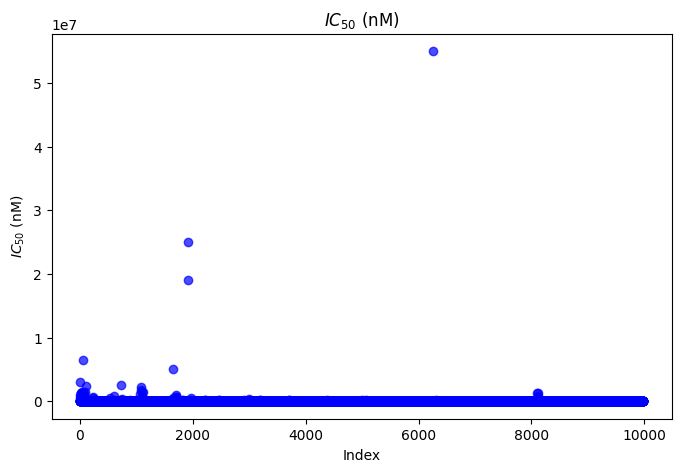

In [127]:
# Scatterplot IC50 values versus index
plt.figure(figsize=(8, 5))
plt.scatter(output_df.index, output_df['IC50'], color='blue', alpha=0.7)
plt.title(r"$IC_{50}$ (nM)")
plt.xlabel("Index")
plt.ylabel(r"$IC_{50}$ (nM)")
plt.show()

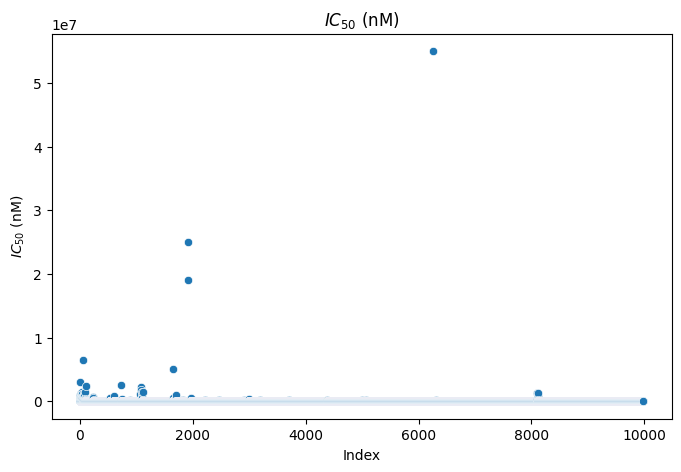

In [128]:
# Scatterplot avec seaborn
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=output_df, 
    x=output_df.index, 
    y='IC50')
plt.title(r"$IC_{50}$ (nM)")
plt.xlabel("Index")
plt.ylabel(r"$IC_{50}$ (nM)")
plt.show()

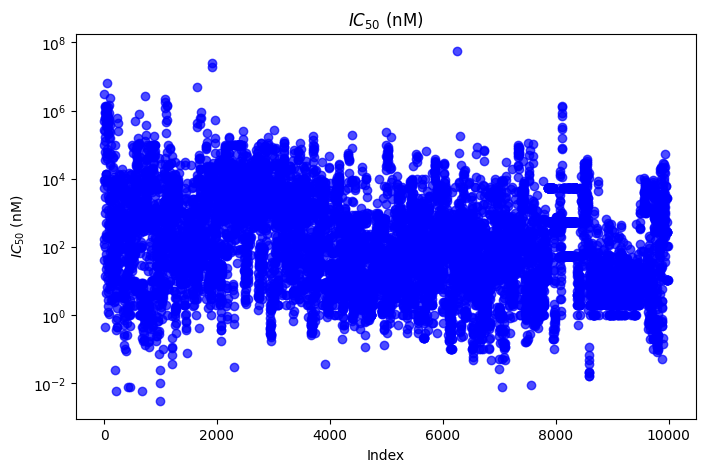

In [129]:
# Scatterplot with a log scale on y axis
plt.figure(figsize=(8, 5))
plt.scatter(
    output_df.index, 
    output_df['IC50'], 
    color='blue', 
    alpha=0.7
)
plt.title(r"$IC_{50}$ (nM)")
plt.xlabel("Index")
plt.ylabel(r"$IC_{50}$ (nM)")
yscale='log'
plt.yscale(yscale)
plt.show()

### Convert $IC_{50}$ to $pIC_{50} = -\log_{10}(IC_{50}$ in M)

In [130]:
# Create a fonction to convert IC50 (nM) in pIC50
def IC50_to_pIC50(IC50):
    """Convert IC50 values in nM to pIC50 values."""
    if IC50 > 0:
        return 9 - math.log10(IC50)
    else:
        return float('nan')

In [131]:
# Apply the conversion to the dataframe
output_df['pIC50'] = output_df['IC50'].map(IC50_to_pIC50)

In [132]:
# Explore data: dataframe sizes and display the first 3 rows
print(f"Output DataFrame shape: {output_df.shape}")
output_df.head(3)

Output DataFrame shape: (9983, 5)


,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517


In [133]:
# Numpy version to improve performance with big dataframes
output_df['pIC50np'] = np.where(
    output_df['IC50'] > 0,
    -np.log10(output_df['IC50']*1e-9), # 1e-9 = 10**-9
    np.nan
)

In [134]:
print(f"Output DataFrame shape: {output_df.shape}")
output_df.head(3)

Output DataFrame shape: (9983, 6)


,molecule_chembl_id,IC50,units,smiles,pIC50,pIC50np
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216,7.387216
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551,6.769551
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517,5.031517


In [135]:
# Delete pIC50np
del output_df['pIC50np']

# With drop
# output_df = output_df.drop(columns=['pIC50np'], inplace=True)

# With pop
# output_df.pop('pIC50np')

### $ pIC_{50} $ distribution


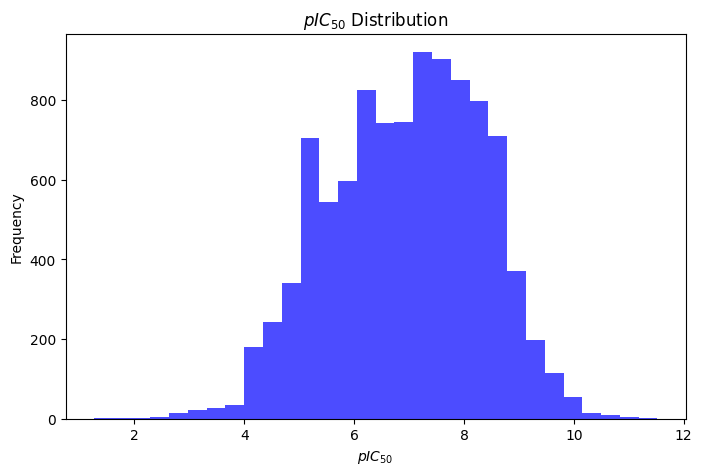

In [136]:
# Matplotlib : plot an histogramm of pIC50
plt.figure(figsize=(8, 5))
plt.hist(output_df['pIC50'], bins=30, color='blue', alpha=0.7)
plt.title(r"$pIC_{50}$ Distribution")
plt.xlabel(r"$pIC_{50}$")
plt.ylabel("Frequency")
plt.show()

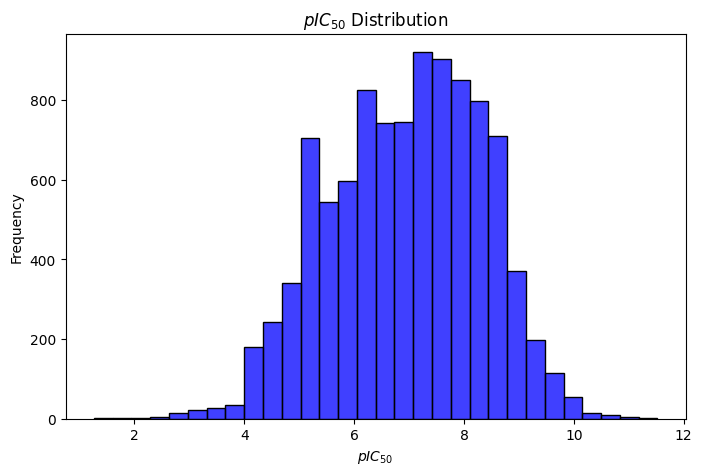

In [137]:
# Seaborn
plt.figure(figsize=(8, 5))
sns.histplot(
    data=output_df, 
    x='pIC50', 
    bins=30, 
    kde=False, 
    color='blue'
)
plt.title(r"$pIC_{50}$ Distribution")
plt.xlabel(r"$pIC_{50}$")
plt.ylabel("Frequency")
plt.show()

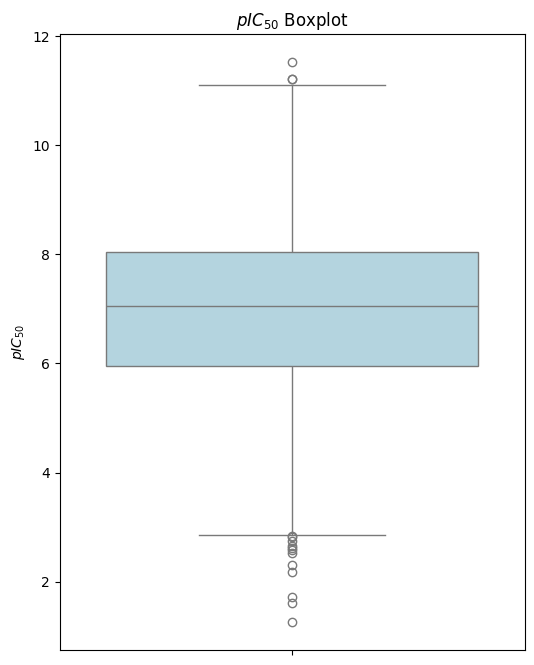

In [138]:
### Boxplot with seaborn
plt.figure(figsize=(6, 8))
sns.boxplot(
    data=output_df, 
    y='pIC50', 
    color='lightblue'
)
plt.title(r"$pIC_{50}$ Boxplot")
plt.ylabel(r"$pIC_{50}$")
plt.show()

## Visualise the most active compounds

### Sort compounds by pIC50 values and reset index

In [139]:
output_df.sort_values(by='pIC50', ascending=False, inplace=True)
output_df.reset_index(drop=True, inplace=True)

In [140]:
# Display the first 3 rows 
output_df.head(3)

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849


### Add a structure column and look at the molecules with the pIC50 corresponding to the most active compounds.

#### PandasTools

In [141]:
help(PandasTools.AddMoleculeColumnToFrame)

Help on function AddMoleculeColumnToFrame in module rdkit.Chem.PandasTools:

AddMoleculeColumnToFrame(
    frame,
    smilesCol='Smiles',
    molCol='ROMol',
    includeFingerprints=False
)
    Converts the molecules contains in "smilesCol" to RDKit molecules and appends them to the
    dataframe "frame" using the specified column name.
    If desired, a fingerprint can be computed and stored with the molecule objects to accelerate
    substructure matching



In [142]:
PandasTools.AddMoleculeColumnToFrame?

Signature:
PandasTools.AddMoleculeColumnToFrame(
    frame,
    smilesCol='Smiles',
    molCol='ROMol',
    includeFingerprints=False,
)
Docstring:
Converts the molecules contains in "smilesCol" to RDKit molecules and appends them to the
dataframe "frame" using the specified column name.
If desired, a fingerprint can be computed and stored with the molecule objects to accelerate
substructure matching
File:      ~/Enseignement/GSON/gson_sbc/.venv/lib/python3.14/site-packages/rdkit/Chem/PandasTools.py
Type:      function

In [143]:
# Add molecule column to output_df
PandasTools.AddMoleculeColumnToFrame(
    output_df,
    smilesCol = 'smiles',
    molCol='ROMol',
)

DataFrame shape: (9983, 6)


,molecule_chembl_id,IC50,units,smiles,pIC50,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,

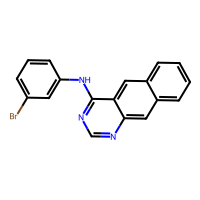
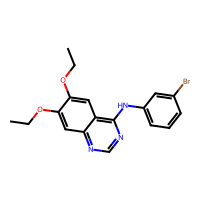

In [144]:
print(f"DataFrame shape: {output_df.shape}")
output_df.head(2)

#### MolFromSmiles

In [145]:
# Add a molecule column 'ROMol2' from the 'smiles' column with a lambda function
output_df['ROMol2'] = output_df['smiles'].map(lambda x: Chem.MolFromSmiles(x) if x else None)

,molecule_chembl_id,IC50,units,smiles,pIC50,ROMol,ROMol2
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,,
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,,

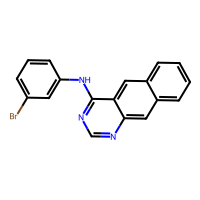
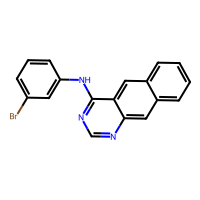
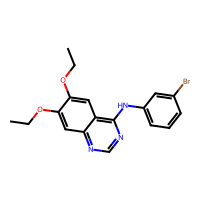
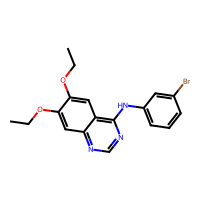

In [146]:
output_df.head(2)

In [147]:
# Delete ROMol2
del output_df['ROMol2']

### Visualisation

,molecule_chembl_id,IC50,units,smiles,pIC50,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,

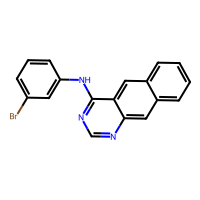
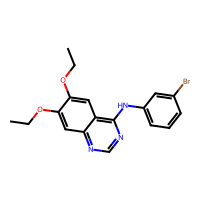
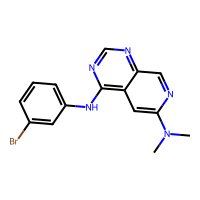

In [148]:
top_n = 3
output_df.head(top_n)

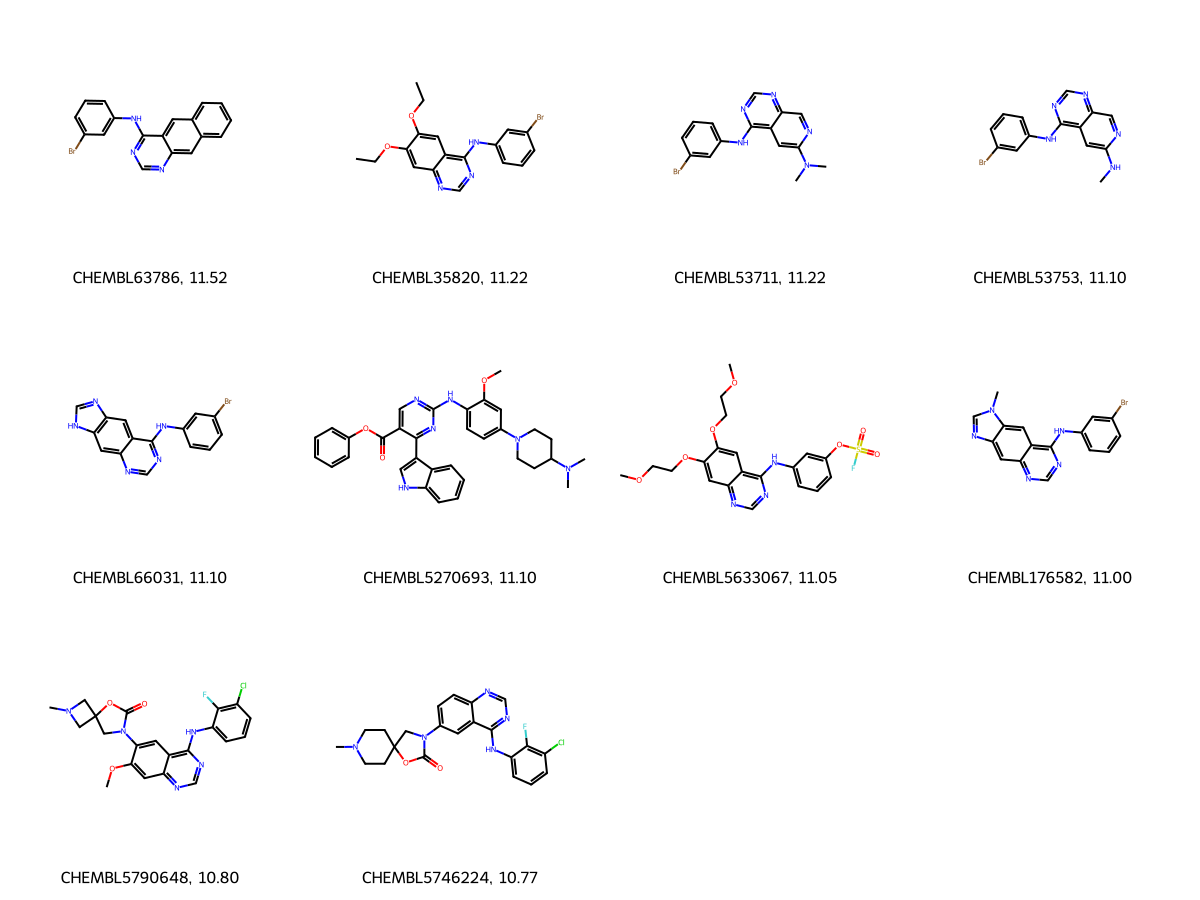

In [149]:
# Draw an image of the top10 compounds, with chembl_id and pIC50 as legends
top_n = 10

mols = [mol for mol in output_df['ROMol'].head(top_n)]
legend = [
    (chembl_id, f"{pIC50:.2f}") 
    for chembl_id, pIC50 in zip(
        output_df['molecule_chembl_id'].head(top_n), 
        output_df['pIC50'].head(top_n)
    )
]


img = Draw.MolsToGridImage(
    mols=mols,
    molsPerRow=4,  # Number of molecules per row
    subImgSize=(300, 300),  # Size of each sub-image
    legends=[f"{chembl_id}, {pIC50}" for chembl_id, pIC50 in legend],  # Add IDs and pIC50 as legends
    useSVG=False  # Generate a PNG image
)

img

In [150]:
# Save the image in PNG format
image_file_path = DATA / f'img_top{top_n}_EGFR_CHEMBL36.png'
with open(image_file_path, 'wb') as f:
    f.write(img.data)

## Save data without the last columns

DataFrame shape: (9983, 6)


,molecule_chembl_id,IC50,units,smiles,pIC50,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,

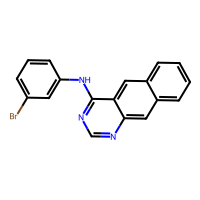
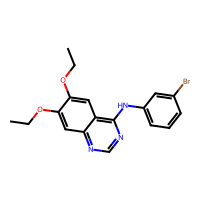

In [151]:
print(f"DataFrame shape: {output_df.shape}")
output_df.head(2)

In [152]:
# Enumerate dataframe's columns
output_df.columns

Index(['molecule_chembl_id', 'IC50', 'units', 'smiles', 'pIC50', 'ROMol'], dtype='object')

In [153]:
# Select all the columns except the last
selected_columns = output_df.columns.to_list()[:-1]
print(f'Selected columns: {selected_columns}')

Selected columns: ['molecule_chembl_id', 'IC50', 'units', 'smiles', 'pIC50']


In [154]:
# Save data in a csv file
output_csv_file_path = DATA / 'EGFR_CHEMBL36_output.csv'
output_df[selected_columns].to_csv(output_csv_file_path)